In [4]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import sunpy.visualization.colormaps as sunpycm
import torch
from omegaconf import OmegaConf
from loguru import logger as lgr_logger

from sdofmv2.core import MAE, MAE_old, SDOMLDataModule
from sdofmv2.utils import ALL_WAVELENGTHS, ALL_COMPONENTS

In [2]:
cfg = OmegaConf.load(
    "../../configs/pretrain/pretrain_mae_ALL.yaml"
    )

# cfg_old = OmegaConf.load(
#     "../../configs/pretrain/pretrain_mae_AIA_old.yaml"
# )

In [3]:
data_module = SDOMLDataModule(
    hmi_path=os.path.join(
        cfg.data.sdoml.base_directory, 
        cfg.data.sdoml.sub_directory.hmi
    ) if cfg.data.sdoml.sub_directory.hmi else None,
    aia_path=os.path.join(
        cfg.data.sdoml.base_directory,
        cfg.data.sdoml.sub_directory.aia,
    ) if cfg.data.sdoml.sub_directory.aia else None,
    eve_path=None,
    components=cfg.data.sdoml.components,
    wavelengths=cfg.data.sdoml.wavelengths,
    ions=cfg.data.sdoml.ions,
    batch_size=cfg.model.misc.batch_size,
    num_workers=cfg.data.num_workers,
    train_index=cfg.data.train_index,
    val_index=cfg.data.val_index,
    test_index=cfg.data.test_index,
    num_frames=cfg.model.mae.num_frames,
    drop_frame_dim=cfg.data.drop_frame_dim,
    apply_mask=cfg.data.sdoml.apply_mask,
    precision=cfg.experiment.precision,
    normalization=cfg.data.sdoml.normalization,
    normalization_stat_path="../../assets/cache/ALL/",
)
data_module.setup()


# data_module_for_old = SDOMLDataModule(
#     hmi_path=os.path.join(
#         cfg_old.data.sdoml.base_directory, 
#         cfg_old.data.sdoml.sub_directory.hmi
#     ) if cfg_old.data.sdoml.sub_directory.hmi else None,
#     aia_path=os.path.join(
#         cfg_old.data.sdoml.base_directory,
#         cfg_old.data.sdoml.sub_directory.aia,
#     ) if cfg_old.data.sdoml.sub_directory.aia else None,
#     eve_path=None,
#     components=cfg_old.data.sdoml.components,
#     wavelengths=cfg_old.data.sdoml.wavelengths,
#     ions=cfg_old.data.sdoml.ions,
#     frequency=cfg_old.data.sdoml.frequency,
#     batch_size=cfg_old.model.misc.batch_size,
#     num_workers=cfg_old.data.num_workers,
#     val_months=cfg_old.data.month_splits.val,
#     test_months=cfg_old.data.month_splits.test,
#     holdout_months=cfg_old.data.month_splits.holdout,
#     cache_dir=os.path.join(
#         "../../assets",
#         cfg_old.data.sdoml.sub_directory.cache,
#     ),
#     min_date=cfg_old.data.min_date,
#     max_date=cfg_old.data.max_date,
#     num_frames=cfg_old.model.mae.num_frames,
#     drop_frame_dim=cfg_old.data.drop_frame_dim,
#     apply_mask=cfg_old.data.sdoml.apply_mask,
#     precision=cfg_old.experiment.precision,
#     normalization=cfg_old.data.sdoml.normalization,
# )
# data_module_for_old.setup()

2026-05-08 20:41:18.679 | INFO     | sdofmv2.core.datamodule:setup:618 - Train dataloader is ready!
2026-05-08 20:41:18.679 | INFO     | sdofmv2.core.datamodule:setup:619 - Dataset size: 223044
2026-05-08 20:41:18.694 | INFO     | sdofmv2.core.datamodule:setup:637 - Validation dataloader is ready!
2026-05-08 20:41:18.694 | INFO     | sdofmv2.core.datamodule:setup:638 - Dataset size: 23123
2026-05-08 20:41:18.711 | INFO     | sdofmv2.core.datamodule:setup:656 - test dataloader is ready!
2026-05-08 20:41:18.711 | INFO     | sdofmv2.core.datamodule:setup:657 - Dataset size: 24618


In [6]:
aia_list = (
    ALL_WAVELENGTHS
    if cfg.data.sdoml.sub_directory.aia and cfg.data.sdoml.wavelengths is None
    else cfg.data.sdoml.wavelengths or []
)

hmi_list = (
    ALL_COMPONENTS
    if cfg.data.sdoml.sub_directory.hmi and cfg.data.sdoml.components is None
    else cfg.data.sdoml.components or []
)

aia_list.sort()
hmi_list.sort()
chan_types = aia_list + hmi_list

cms = [
    sunpycm.cmlist.get("sdoaia131"),
    sunpycm.cmlist.get("sdoaia1600"),
    sunpycm.cmlist.get("sdoaia1700"),
    sunpycm.cmlist.get("sdoaia171"),
    sunpycm.cmlist.get("sdoaia193"),
    sunpycm.cmlist.get("sdoaia211"),
    sunpycm.cmlist.get("sdoaia304"),
    sunpycm.cmlist.get("sdoaia335"),
    sunpycm.cmlist.get("sdoaia94"),
    sunpycm.cmlist.get("hmi"),
    sunpycm.cmlist.get("hmi"),
    sunpycm.cmlist.get("hmi"),
]

In [7]:
# wavelenghs = ALL_WAVELENGTHS
# wavelenghs.sort()

# wave_val_list = []
# for wave in wavelenghs:
#     val = wave[:-1]
#     wave_val_list.append(int(val))

# wave_arr = np.array(wave_val_list)
# sort_ids = np.argsort(wave_arr)

# cms = [
#     sunpycm.cmlist.get("sdoaia131"),
#     sunpycm.cmlist.get("sdoaia1600"),
#     sunpycm.cmlist.get("sdoaia1700"),
#     sunpycm.cmlist.get("sdoaia171"),
#     sunpycm.cmlist.get("sdoaia193"),
#     sunpycm.cmlist.get("sdoaia211"),
#     sunpycm.cmlist.get("sdoaia304"),
#     sunpycm.cmlist.get("sdoaia335"),
#     sunpycm.cmlist.get("sdoaia94"),
#     sunpycm.cmlist.get("hmi"),
#     sunpycm.cmlist.get("hmi"),
#     sunpycm.cmlist.get("hmi"),
# ]

In [8]:
ckpt_dir = "../../assets/checkpoints/backbone/ALL/"
model = MAE.load_from_checkpoint(
    checkpoint_path=ckpt_dir+"id_uj0jxwrn_mae_epoch=13-val_loss=0.05.ckpt", 
    map_location="cpu",
    weights_only=False)
lgr_logger.info(f"masking ratio of sdofmv2: {model.masking_ratio}")

2026-05-08 20:43:20.827 | INFO     | __main__:<module>:6 - masking ratio of sdofmv2: 0.0


In [17]:
timestamps = [
    "2010-12-01 00:00:00",
    # "2012-12-25 00:12:00",
    # "2013-12-25 00:12:00",
    ]

img_indices = [
    data_module.test_ds.aligndata.index.get_loc(
        pd.to_datetime(i_time)
    ) for i_time in timestamps
]
x_set = torch.cat([data_module.test_ds[i][0].unsqueeze(0) for i in img_indices], dim=0)
ts = [pd.to_datetime(data_module.test_ds[i][1]) for i in img_indices]

print(f"Datetime: {ts}")

Datetime: [Timestamp('2010-12-01 00:00:00')]


In [18]:
model.eval()

with torch.no_grad():
    output = model(x_set)

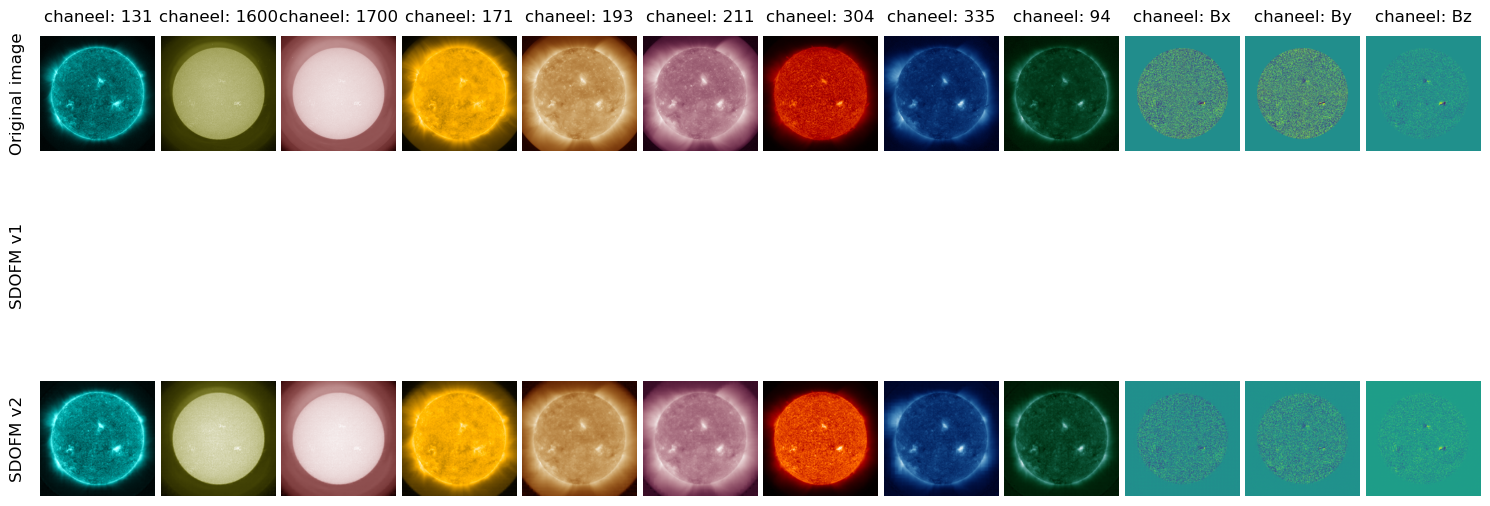

In [21]:
fig, axes = plt.subplots(nrows=3, ncols=12, figsize=(16, 6))

for ax in axes.flat:
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

ch_info = ["131", "1600", "1700", "171", "193", "211", "304", "335", "94", "Bx", "By", "Bz"]


for i, col in enumerate(chan_types):
    
    axes[0][i].set_title(f"chaneel: {ch_info[i]}", fontsize=12, pad=10)
    # --- Row 0: Original Image ---
    axes[0][i].imshow(x_set[0, i, 0, :, :], cmap=cms[i])
    # --- Row 1: SDOFM v1 ---
    # axes[1][i].imshow(output_old[1][0, col, 0, :, :] * model.limb_mask, cmap=cms[col])
    # axes[1][i].imshow(output_old[1][0, col, 0, :, :], cmap=cms[col])
    # --- Row 2: SDOFM v2 ---
    # axes[2][i].imshow(output[0][0, col, 0, :, :] * model.limb_mask, cmap=cms[col])
    axes[2][i].imshow(output[0][0, i, 0, :, :], cmap=cms[i])

row_info = ["Original image", "SDOFM v1", "SDOFM v2"]

for row_idx in range(3):
    axes[row_idx][0].text(
        -0.2, 0.5,              # Negative x moves it to the left
        f"{row_info[row_idx]}", 
        ha='center', 
        va='center', 
        fontsize=12, 
        rotation=90,
        transform=axes[row_idx][0].transAxes # Ensures coordinates are relative to the subplot
    )

plt.subplots_adjust(wspace=0.05, hspace=0.05, left=0.05, right=0.95, top=0.9, bottom=0.05)

plt.savefig(f"SDOFMv2_results_per_wavelengh_{ts[0]}.pdf", dpi=300, bbox_inches="tight")
plt.show()

TypeError: unsupported operand type(s) for *: 'Tensor' and 'NoneType'

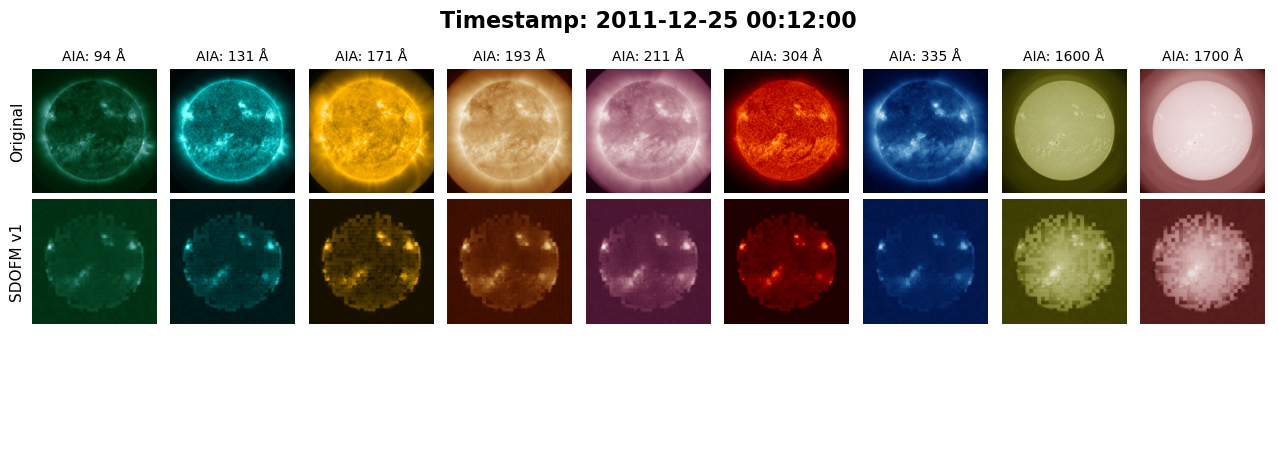

In [9]:
# Data setup (assuming your variables x_set, output, cms, sort_ids, ts exist)
ch_info = ["131", "1600", "1700", "171", "193", "211", "304", "335", "94"]
row_labels = ["Original", "SDOFM v1", "SDOFM v2"]

fig = plt.figure(figsize=(16, 18))
outer_grid = gridspec.GridSpec(len(ts), 1, hspace=0.3, figure=fig)

for t_i, timestamp in enumerate(ts):
    inner_grid = gridspec.GridSpecFromSubplotSpec(3, 9, 
                                                  subplot_spec=outer_grid[t_i], 
                                                  wspace=0.05, hspace=0.05)
    
    # --- Add Timestamp Title ---
    ax_header = plt.Subplot(fig, outer_grid[t_i])
    fig.add_subplot(ax_header)
    ax_header.set_title(f"Timestamp: {timestamp}", fontsize=16, weight='bold', pad=30)
    ax_header.axis('off') # Hide the axis lines, just keep the title

    for row_idx in range(3): # Loop: Original, v1, v2
        for col_idx, ch_id in enumerate(sort_ids):
            
            # Create the subplot in the inner grid
            ax = plt.Subplot(fig, inner_grid[row_idx, col_idx])
            fig.add_subplot(ax)
            
            # Turn off spines/ticks for clean look
            ax.set_xticks([])
            ax.set_yticks([])
            for spine in ax.spines.values():
                spine.set_visible(False)
            
            # --- Plotting Logic ---
            if row_idx == 0:
                img_data = x_set[t_i, ch_id, 0, :, :]

                if t_i == 0:
                    ax.set_title(f"AIA: {ch_info[ch_id]} Å", fontsize=10)
                    
            elif row_idx == 1:
                # SDOFM v1
                img_data = output_old[1][t_i, ch_id, 0, :, :]
            elif row_idx == 2:
                # SDOFM v2
                img_data = output[0][t_i, ch_id, 0, :, :] * model.limb_mask
            
            ax.imshow(img_data, cmap=cms[ch_id])

            if col_idx == 0:
                ax.set_ylabel(row_labels[row_idx], fontsize=11, rotation=90, labelpad=5)

plt.savefig(f"SDOFMv2_Refined_{ts}.pdf", dpi=300, bbox_inches="tight")
plt.show()